# Forensic-Aware Data Augmentation

Standard augmentations (e.g., flip, rotate) can destroy the "GAN fingerprints" that the model tries to find. In order to tackle this, we experiment with "forensic-aware" augmentations: 

- JPEG/Compression Augmentation : To mimic the Deepfakes on social media which are heavily compressed, we augment the training data with random JPEG quality levels (30–90).  

- Face-Cutout / Block-Masking : We randomly mask out the eyes or mouth during training. This prevents the model from relying on just one feature and forces it to learn the global "texture" of a fake.

- Frequency Domain Mixup : We apply a Fourier Transform and add noise to the high-frequency components as Deepfakes usually have distinct "ringing" artifacts in the frequency domain.

These can help the model learn to focus on the relevant features for deepfake detection and improve its robustness to various types of manipulations.

##### Import libraries

In [ ]:
import io
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import os
import sys
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchaudio.transforms as transforms
from torch.utils.data import Dataset, DataLoader

curr_dir = os.getcwd()
root_dir = os.path.dirname(curr_dir)
data_dir = os.path.join(root_dir, 'data')

if root_dir not in sys.path:
	sys.path.append(root_dir)

import aceverify

# Setting HuggingFace token for accessing pretrained models faster
os.environ['HF_HOME'] = os.path.join(root_dir, 'huggingface')
os.environ['HF_TOKEN'] = "" # TODO: Update with your HuggingFace token

##### Defining Custom Augmentation Class

In [15]:
class ForensicAugmentor:
    def __init__(self, p=0.5, cutout_p=0.3):
        self.p = p
        self.cutout_p = cutout_p

    # JPEG/Compression Augmentation
    def apply_compression(self, image_tensor):
        """Simulates social media compression artifacts."""
        if np.random.rand() > self.p:
            return image_tensor
        
        # Convert tensor to PIL to simulate JPEG encoding
        img = Image.fromarray((image_tensor * 255).astype(np.uint8)) # NOTE: fromarray() assumes uint8 range of [0, 255]
        quality = np.random.randint(30, 90)
        
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=quality)
        img_compressed = Image.open(buffer).convert("RGB") # NOTE: Forcing RGB for consistency
        
        return np.array(img_compressed) / 255.0

    # Face-Cutout / Block-Masking
    def apply_face_cutout(self, image_tensor, block_size=32):
        """Masks random patches to force model to learn global features."""
        if np.random.rand() > self.cutout_p:
            return image_tensor
        
        img = image_tensor.copy()
        h, w, _ = img.shape
        
        bs = min(block_size, h - 1, w - 1)
        if bs <= 0:
            return img
        
        y = np.random.randint(0, h - block_size)
        x = np.random.randint(0, w - block_size)
        
        img[y:y+block_size, x:x+block_size, :] = 0
        return img

    # Frequency Domain Mixup
    def apply_freq_mixup(self, image):
        """Injects noise into the high-frequency spectrum."""
        if np.random.rand() > self.p:
            return image
        
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() # NOTE: torch.fft needs [C, H, W]
        # FFT to move to Frequency Domain
        fft = torch.fft.fftn(image_tensor, dim=(-2, -1))
        fft_shift = torch.fft.fftshift(fft)
        
        # Add noise to the high-frequency components (edges/corners of the shift)
        noise = torch.randn_like(fft_shift) * 0.1
        fft_shift += noise
        
        # Inverse FFT back to Spatial Domain
        ifft_shift = torch.fft.ifftshift(fft_shift)
        img_back = torch.fft.ifftn(ifft_shift, dim=(-2, -1))
        
        # Convert back to numpy [H,W,C] and clamp
        result = torch.real(img_back).permute(1, 2, 0).numpy()
        return np.clip(result, 0, 1)  # fix: clamp to valid display range

##### Augmentating Sample Input 

In [16]:
def show_alignment_impact(original_frame, augmented_frame, aug_method):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(original_frame)
    ax[0].set_title(f"Original Frame ({aug_method})")
    ax[0].axis("off")

    ax[1].imshow(augmented_frame)
    ax[1].set_title(f"Augmented Frame ({aug_method})")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

In [17]:
test_data_path = os.path.join(data_dir, "test_data.h5")
test_loader = aceverify.ACEDataset(h5_path=test_data_path, is_training=False)
augmentor = ForensicAugmentor()

# Pick Random Image
rand_ind = np.random.randint(len(test_loader))
video, *_ = test_loader[rand_ind]                                  # [C, T, H, W]
first_frame = video[:, 0, :, :]                                    # [C, H, W]
original_video_frame = first_frame.permute(1,2,0).cpu().numpy()    # [H, W, C] -> [0,1]

Compression Augmentation

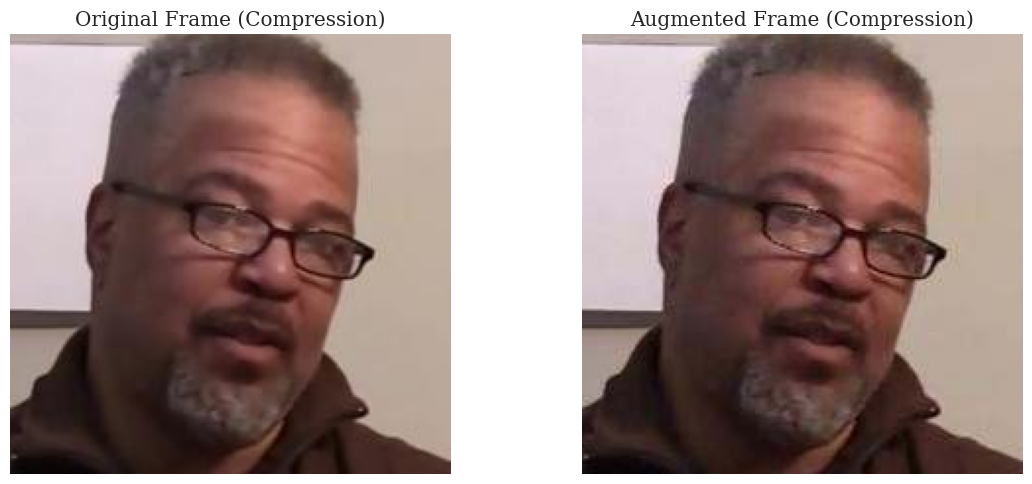

In [18]:
compressed_video_frame = augmentor.apply_compression(original_video_frame)
show_alignment_impact(original_video_frame, compressed_video_frame, "Compression")

Face-Cutout Augmentation

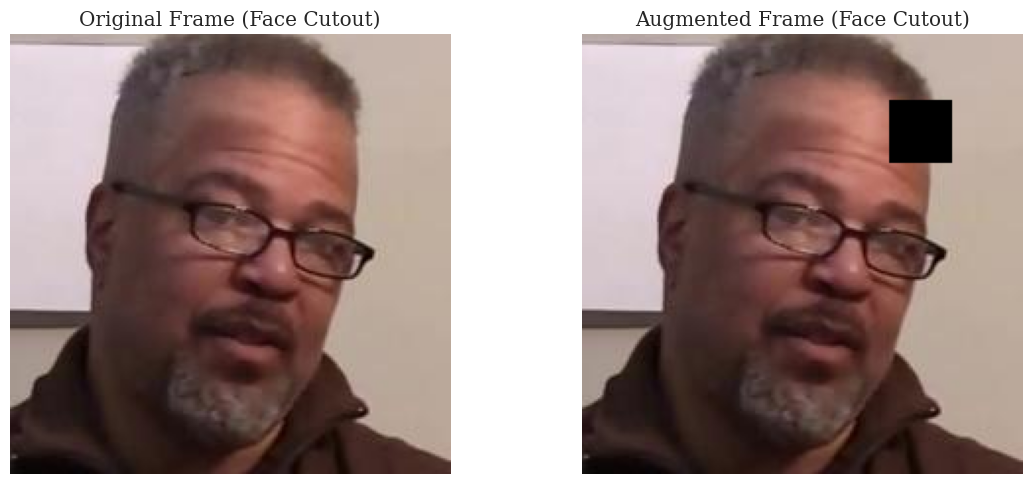

In [37]:
augmented_frame = augmentor.apply_face_cutout(original_video_frame)
show_alignment_impact(original_video_frame, augmented_frame, "Face Cutout")

Frequency Domain Mixup

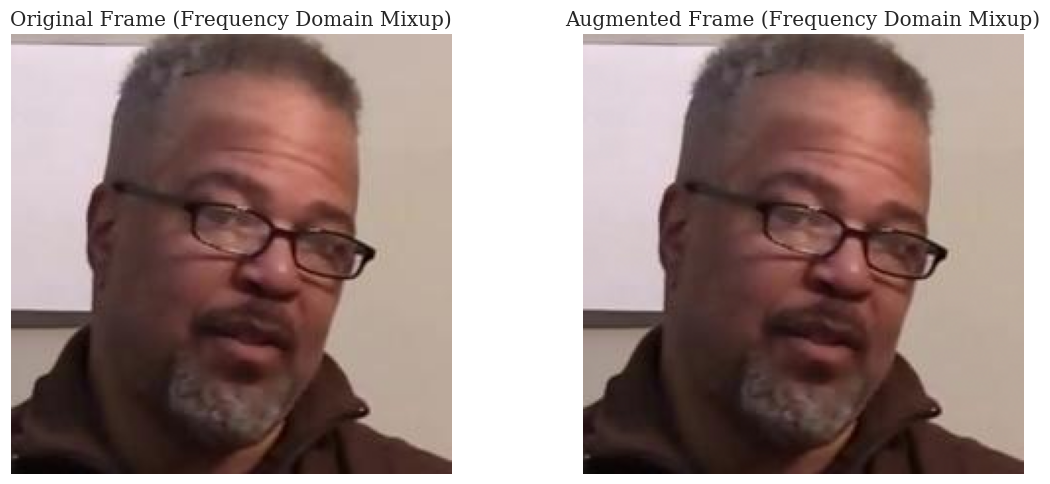

In [20]:
augmented_frame = augmentor.apply_freq_mixup(original_video_frame)
show_alignment_impact(original_video_frame, augmented_frame, "Frequency Domain Mixup")

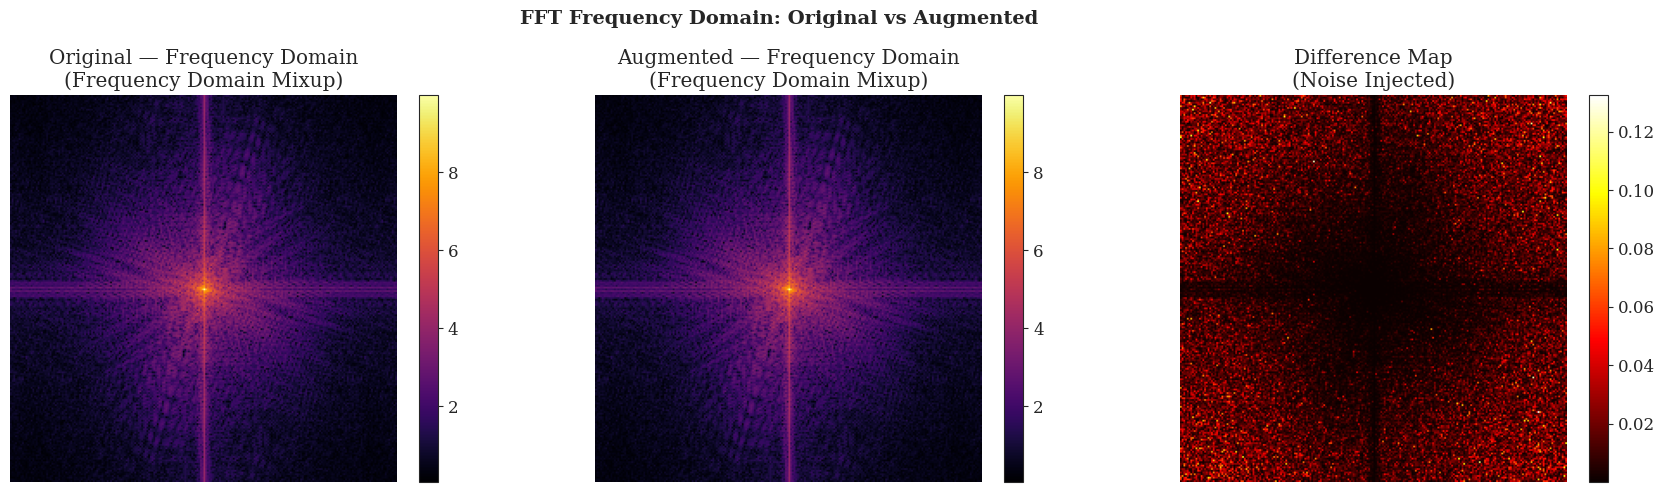

In [21]:
def show_frequency_domain(original_frame, aug_method):
    """
    Visualizes original vs augmented image in the frequency domain.
    original_frame: numpy array [H, W, C] float [0, 1]
    """
    def compute_fft_magnitude(img_np):
        """Convert [H,W,C] numpy to log-magnitude spectrum, averaged over channels."""
        t = torch.from_numpy(img_np).permute(2, 0, 1).float()  # [C, H, W]
        fft = torch.fft.fftn(t, dim=(-2, -1))
        fft_shift = torch.fft.fftshift(fft)
        magnitude = torch.abs(fft_shift)
        log_magnitude = torch.log1p(magnitude)                  # log scale for visibility
        return log_magnitude.mean(dim=0).numpy()                # average over channels [H, W]

    def compute_augmented_fft_magnitude(img_np):
        """Returns fft_shift magnitude AFTER noise injection (from apply_freq_mixup)."""
        t = torch.from_numpy(img_np).permute(2, 0, 1).float()  # [C, H, W]
        fft = torch.fft.fftn(t, dim=(-2, -1))
        fft_shift = torch.fft.fftshift(fft)

        # Same noise injection as apply_freq_mixup
        noise = torch.randn_like(fft_shift) * 0.1
        fft_shift_noisy = fft_shift + noise

        magnitude = torch.abs(fft_shift_noisy)
        log_magnitude = torch.log1p(magnitude)
        return log_magnitude.mean(dim=0).numpy()                # [H, W]

    original_mag  = compute_fft_magnitude(original_frame)
    augmented_mag = compute_augmented_fft_magnitude(original_frame)
    diff          = np.abs(augmented_mag - original_mag)        # highlight changes

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(original_mag, cmap="inferno")
    axes[0].set_title(f"Original — Frequency Domain\n({aug_method})")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(augmented_mag, cmap="inferno")
    axes[1].set_title(f"Augmented — Frequency Domain\n({aug_method})")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(diff, cmap="hot")
    axes[2].set_title("Difference Map\n(Noise Injected)")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle("FFT Frequency Domain: Original vs Augmented", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Visualize augmentation in Frequency Domain
show_frequency_domain(original_video_frame, "Frequency Domain Mixup")

##### Integration into ACEDataset

In [22]:
class ACEDataset_with_Aug(aceverify.ACEDataset):
    def __init__(self, h5_path, indices=None, is_training=False, p=0.3, cutout_p=0.3):
        super().__init__(h5_path, indices, is_training)
        self.aug = ForensicAugmentor(p=p, cutout_p=cutout_p)

    def __getitem__(self, idx):
        sample = super(ACEDataset_with_Aug, self).__getitem__(idx)

        if isinstance(sample, tuple):
            video, *rest = sample
        else:
            video, rest = sample, []

        # Normalize to [T, C, H, W] for frame-wise augmentation
        was_cthw = (video.ndim == 4 and video.shape[0] in (1, 3))
        video_tchw = video.permute(1, 0, 2, 3) if was_cthw else video

        if self.is_training:
            augmented_frames = []
            for f in video_tchw:  # [C, H, W]
                f_np = f.permute(1, 2, 0).cpu().numpy()
                f_np = self.aug.apply_freq_mixup(f_np)
                f_np = self.aug.apply_compression(f_np)
                f_np = self.aug.apply_face_cutout(f_np)
                augmented_frames.append(torch.from_numpy(f_np).permute(2, 0, 1).float())
            video_tchw = torch.stack(augmented_frames)

        video_out = video_tchw.permute(1, 0, 2, 3) if was_cthw else video_tchw  # back to [C,T,H,W]
        return (video_out, *rest) if isinstance(sample, tuple) else video_out

##### Training with Normal & Custom Augmentation Class

Defining global settings & hyperparameters

In [23]:
results_log = {}

# Hyperparameters & Parameters for training
epochs = 10
batch_size = 8
learning_rate = 5e-5
train_path = "/rhome/abhar061/shared/ace_verify/data/train_data-003.h5"
test_path = "/rhome/abhar061/shared/ace_verify/data/test_data.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(device))

config = {
    "device":device,
    "criterion": criterion,
    "epochs": epochs,
    "batch_size": batch_size,
    "test_path": test_path,
    "train_path": train_path,
}

SEED = 42

# Fetching common Test Indices for fair comparison amongst all the models
def fixed_balanced_indices(path, n, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(path, "r") as f:
        labels = np.array([f[k].attrs["label"] for k in f.keys()])

    real_indices = np.where(labels == 0)[0]
    fake_indices = np.where(labels == 1)[0]
    num_each = n // 2

    sel_real = rng.choice(real_indices, min(len(real_indices), num_each), replace=False)
    sel_fake = rng.choice(fake_indices, min(len(fake_indices), num_each), replace=False)

    indices = np.concatenate([sel_real, sel_fake])
    rng.shuffle(indices)
    return indices

test_n = 200
test_indices = fixed_balanced_indices(test_path, test_n, seed=SEED)
config["test_indices"] = test_indices

results_dir = os.path.join(root_dir, "results")
os.makedirs(results_dir, exist_ok=True)

def plot_comparison(results):
    sns.set_style("white")
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    
    # Color palette
    colors = sns.color_palette("Set1", n_colors=len(results))
    
    for i, (experiment_name, metrics) in enumerate(results.items()):
        color = colors[i]
        epochs = metrics['epochs']
        
        # Plotting Test Accuracy with Solid Line (-) as it's the Primary Focus
        ax.plot(epochs, metrics['test_accuracies'], 
                label=f"{experiment_name} (Test: {max(metrics['test_accuracies']):.1f}%)", 
                color=color, linestyle='-', linewidth=2.5)
        
        # Plotting Train Accuracy with Dashed Line (--) as it's Secondary Focus
        ax.plot(epochs, metrics['train_accuracies'], 
                label=f"{experiment_name} (Train: {max(metrics['train_accuracies']):.1f}%)", 
                color=color, linestyle='--', linewidth=1.5, alpha=0.7)
        
        # Marking the peak test accuracy
        best_acc = max(metrics['test_accuracies'])
        best_epoch = epochs[metrics['test_accuracies'].index(best_acc)]
        ax.scatter(best_epoch, best_acc, color=color, s=40, edgecolors='black', zorder=5)

    # Labeling and Titles
    ax.set_title("Performance gain from Forensic Aware Data Augmentation Techniques", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Epochs", fontsize=14)
    ax.set_ylabel("Accuracy (%)", fontsize=14)
    
    # Refined Legend
    ax.legend(loc='lower right', frameon=True, fontsize=10, ncol=1)
    
    # Grid and Spines
    ax.grid(True, linestyle='--', alpha=0.6)
    sns.despine() # Removes top and right borders
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "forensic_augmentation_comparison.pdf"), format='pdf', bbox_inches='tight') # Best for LaTeX
    plt.show()

In [27]:
baseline_model = aceverify.ACEVerifyModel().to(device)
optimizer = optim.AdamW(baseline_model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = "aceverify_baseline_final.pth"

config["model"] = baseline_model
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path
config['dataset_class'] = aceverify.ACEDataset

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    baseline_model.load_state_dict(checkpoint)
    trained_baseline_model = baseline_model
    results_log["Baseline"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_baseline_model, results_log["Baseline"] = aceverify.train_model(config)

No checkpoint found. Starting from pretrained ViT weights.


In [28]:
model_with_aug = aceverify.ACEVerifyModel().to(device)
optimizer = optim.AdamW(model_with_aug.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
checkpoint_path = "aceverify_aug_final.pth"

config["model"] = model_with_aug
config["optimizer"] = optimizer
config["scheduler"] = scheduler
config["checkpoint_path"] = checkpoint_path
config["dataset_class"] = ACEDataset_with_Aug # Passing custom dataset class

if os.path.exists(checkpoint_path):
    print(f"Loading trained model from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_with_aug.load_state_dict(checkpoint)
    trained_model_with_aug = model_with_aug
    results_log["With-Aug"] = pd.read_csv(checkpoint_path.replace('.pth', '_metrics.csv')).to_dict(orient='list')
else:
    trained_model_with_aug, results_log["With-Aug"] = aceverify.train_model(config)

No checkpoint found. Starting from pretrained ViT weights.


##### Plotting Results

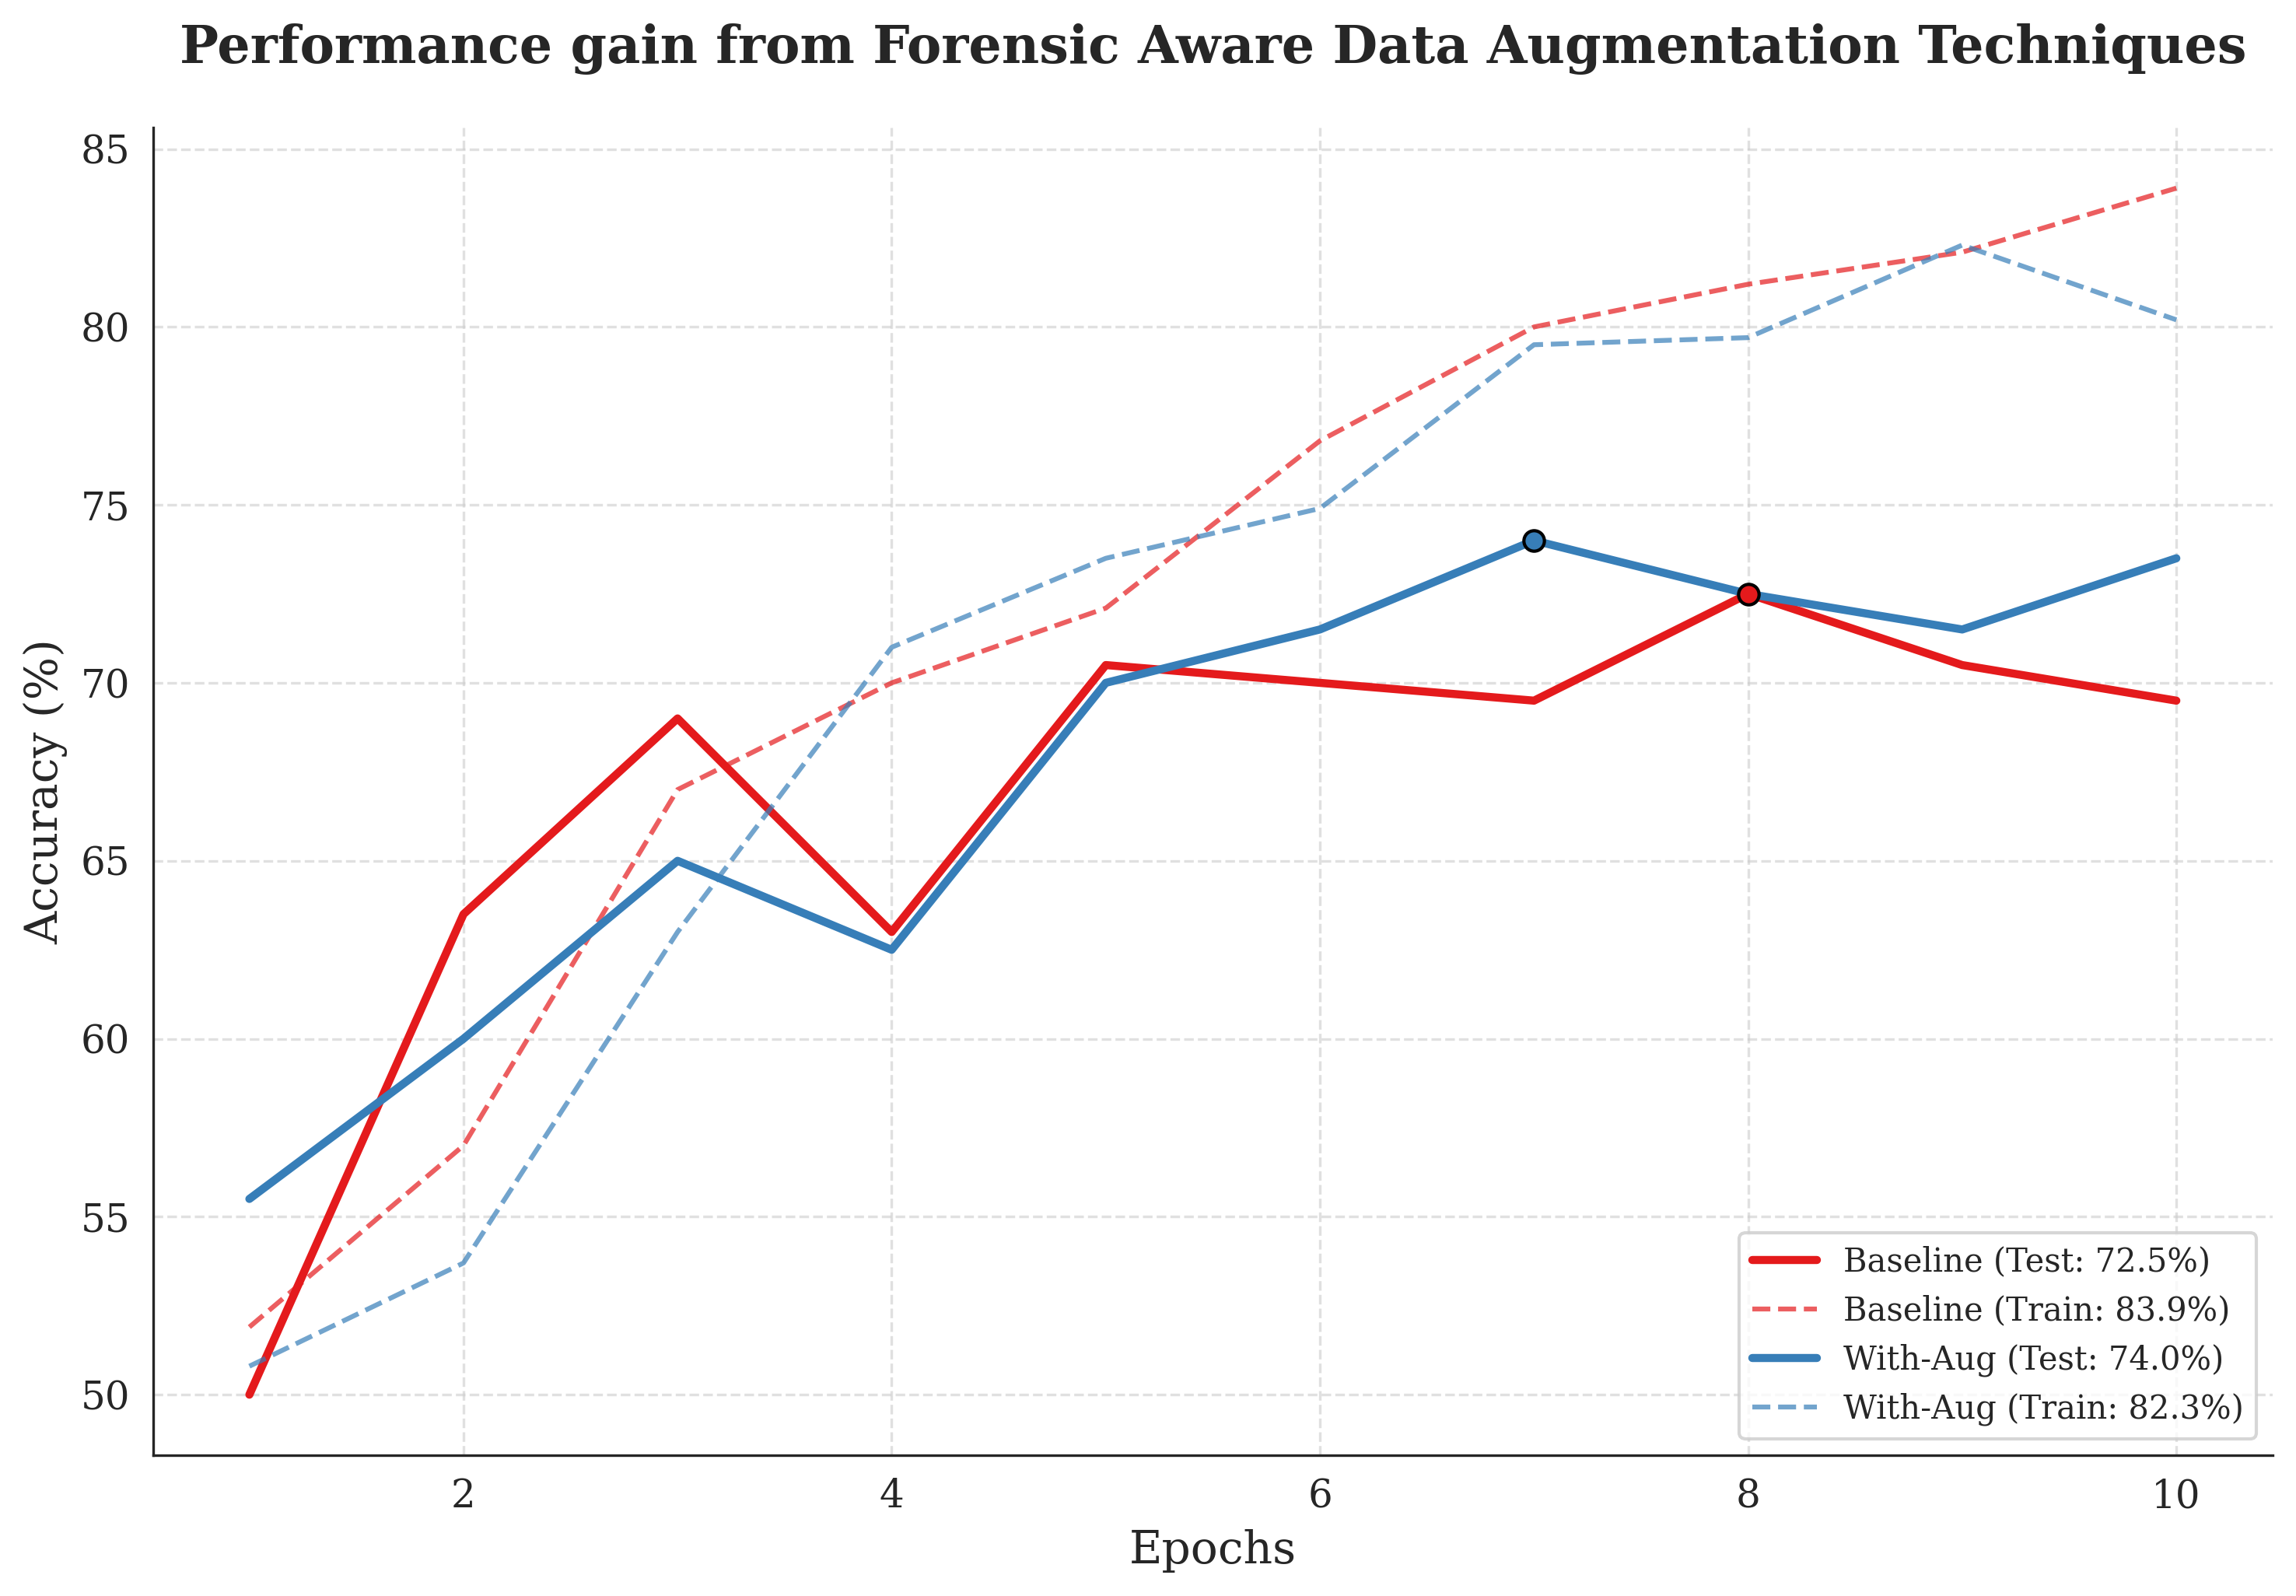

In [29]:
plot_comparison(results_log)

As we can observe from the above results, the forensic-aware augmentations considerably improves the model's performance on the test set (~1.5% increase in test accuracy). This indicates that the model is better at identifying deepfakes without being misled by common augmentations that may destroy important forensic features.